# Clase 6 · Regresión logística: ¿sí o no?

**Módulo 1: Introducción y fundamentos estadísticos** · Diplomado en Ciencia de Datos Aplicada · UTFSM

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/daniopitz/diplomado-cdd/blob/main/06_regresion_logistica_colab.ipynb)

Versión para **Google Colab**. Antes de trabajar, guarde su propia copia con `Archivo > Guardar una copia en Drive`.

**Qué hacemos hoy.** Modelar una respuesta que es sí o no. Primero con los 10.000 clientes de tarjeta de crédito del libro de James et al.: por qué la recta no sirve, la regresión logística, cómo se lee e^b y el mismo summary de siempre. Después con varias variables, en los clientes y en los 891 pasajeros del Titanic. Y al final, clasificar: el umbral, la matriz de confusión, los falsos positivos y falsos negativos, sensibilidad y especificidad, y evaluar el modelo en datos que no vio.

**El hilo de la clase:** el modelo no predice el sí o el no, predice una probabilidad. La decisión, y sus dos errores, la ponemos nosotros.

## 1. Preparación

Las mismas bibliotecas de la clase 5, más `smf` (la API de fórmulas de statsmodels, que usamos para `smf.ols`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

sns.set_theme(style="whitegrid")
%config InlineBackend.figure_format = "retina"
pd.options.display.float_format = "{:.3f}".format

In [2]:
# Los datos se leen directo desde el repositorio del curso en GitHub
BASE = "https://raw.githubusercontent.com/daniopitz/diplomado-cdd/main/datos/clase06/"

**Los datos del ejemplo 1.** `Default.csv` viene con el libro *An Introduction to Statistical Learning* (James, Witten, Hastie y Tibshirani): 10.000 clientes de una tarjeta de crédito, con su deuda en la tarjeta (`balance`: lo que deben después del pago mensual, en dólares), su ingreso anual (`income`) y si son estudiantes. La respuesta es `default`: si dejaron de pagar. Creamos las columnas en español y en escalas cómodas: la deuda en cientos de dólares y el ingreso en miles.

In [3]:
clientes = pd.read_csv(BASE + "default_islr.csv")
clientes["no_paga"] = (clientes["default"] == "Yes").astype(int)   # la respuesta: 1 si dejó de pagar
clientes["estudiante"] = (clientes["student"] == "Yes").astype(int)
clientes["deuda_100"] = clientes["balance"] / 100      # la deuda, en cientos de dólares
clientes["ingreso_miles"] = clientes["income"] / 1000  # el ingreso anual, en miles de dólares
clientes.head()

,default,student,balance,income,no_paga,estudiante,deuda_100,ingreso_miles
0,No,No,729.526,44361.625,0,0,7.295,44.362
1,No,Yes,817.180,12106.135,0,1,8.172,12.106
2,No,No,1073.549,31767.139,0,0,10.735,31.767
3,No,No,529.251,35704.494,0,0,5.293,35.704
4,No,No,785.656,38463.496,0,0,7.857,38.463


## 2. Una respuesta que es sí o no

**Objetivo:** ver qué es una variable 0/1 y qué la resume.

La respuesta `no_paga` vale 1 o 0. La media de una columna de 0 y 1 es la fracción de unos: la **proporción** de clientes que dejaron de pagar. Un cliente tomado al azar es una **Bernoulli** con esa probabilidad $p$, y contar cuántos síes hay entre $n$ clientes es la **binomial** de la clase 5.

clientes: 10000 | dejaron de pagar: 333 | proporción p = 0.033


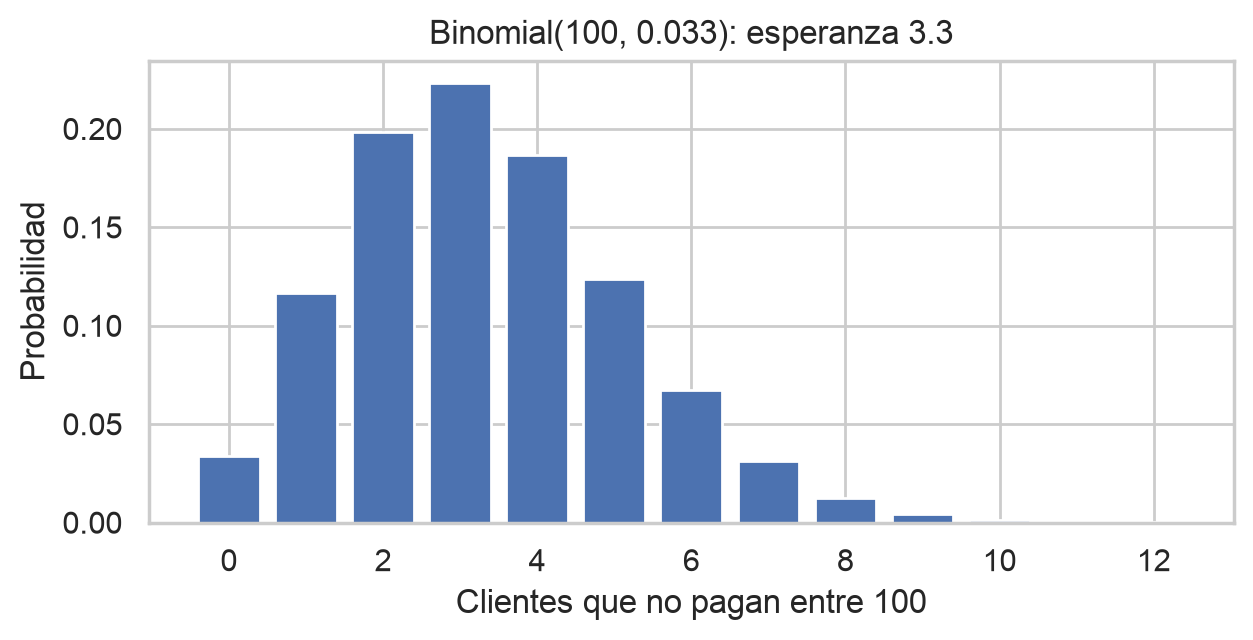

In [4]:
p = clientes["no_paga"].mean()
print(f"clientes: {len(clientes)} | dejaron de pagar: {clientes['no_paga'].sum()} | proporción p = {p:.3f}")

# Entre 100 clientes al azar, ¿cuántos dejan de pagar? Binomial(n=100, p)
k = np.arange(0, 13)
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(k, stats.binom.pmf(k, 100, p))
ax.set(xlabel="Clientes que no pagan entre 100", ylabel="Probabilidad", title=f"Binomial(100, {p:.3f}): esperanza {100 * p:.1f}")
plt.show()

Lo que queremos es que $p$ dependa de $x$: que la probabilidad de no pagar cambie con la deuda. Primero, los datos: la fracción que no paga, por tramo de deuda.

In [5]:
# pd.cut agrupa la deuda en tramos de 300 dólares; en cada tramo se cuenta cuántos clientes hay y cuántos no pagan
clientes["tramo"] = pd.cut(clientes["balance"], np.arange(0, 2701, 300))
por_tramo = clientes.groupby("tramo", observed=True).agg(clientes=("no_paga", "size"), no_pagan=("no_paga", "sum"), deuda=("balance", "mean"))
por_tramo["fraccion"] = por_tramo["no_pagan"] / por_tramo["clientes"]   # la fracción que no paga: la probabilidad estimada en el tramo
por_tramo

,clientes,no_pagan,deuda,fraccion
tramo,,,,
"(0, 300]",998,0,168.815,0.000
"(300, 600]",1784,0,458.584,0.000
"(600, 900]",2308,3,751.196,0.001
"(900, 1200]",2117,19,1041.429,0.009
"(1200, 1500]",1383,53,1333.344,0.038
"(1500, 1800]",623,96,1627.923,0.154
"(1800, 2100]",229,114,1913.010,0.498
"(2100, 2400]",52,41,2209.210,0.788
"(2400, 2700]",7,7,2503.520,1.000


Cada fila es un cálculo simple: entre 1.800 y 2.100 dólares hay 229 clientes y 114 dejaron de pagar, 114 / 229 = 0,50. Esa fracción es la probabilidad de no pagar de ese tramo, estimada con los datos. Casi nadie deja de pagar hasta los 1.500 dólares, y desde los 2.100 lo hace la mayoría: la fracción sube en forma de S, no en línea recta.

## 3. Por qué la recta no sirve

**Objetivo:** ver qué pasa al ajustar la recta de la clase 4 sobre un 0/1.

Nada impide correr `sm.OLS` con `no_paga` como respuesta. El resultado es una recta que intenta ser una probabilidad y no lo logra:

In [6]:
recta = sm.OLS(clientes["no_paga"], sm.add_constant(clientes["deuda_100"])).fit()
a_r, b_r = recta.params
print(f"recta: {a_r:.3f} + {b_r:.4f} · deuda_100")
print(f"predicción con deuda 0: {a_r:.3f}")
print(f"predicción con deuda 2.000: {a_r + b_r * 20:.3f}   (la fracción real en ese tramo es {por_tramo.loc[por_tramo['deuda'].sub(2000).abs().idxmin(), 'fraccion']:.2f})")

recta: -0.075 + 0.0130 · deuda_100
predicción con deuda 0: -0.075
predicción con deuda 2.000: 0.185   (la fracción real en ese tramo es 0.50)


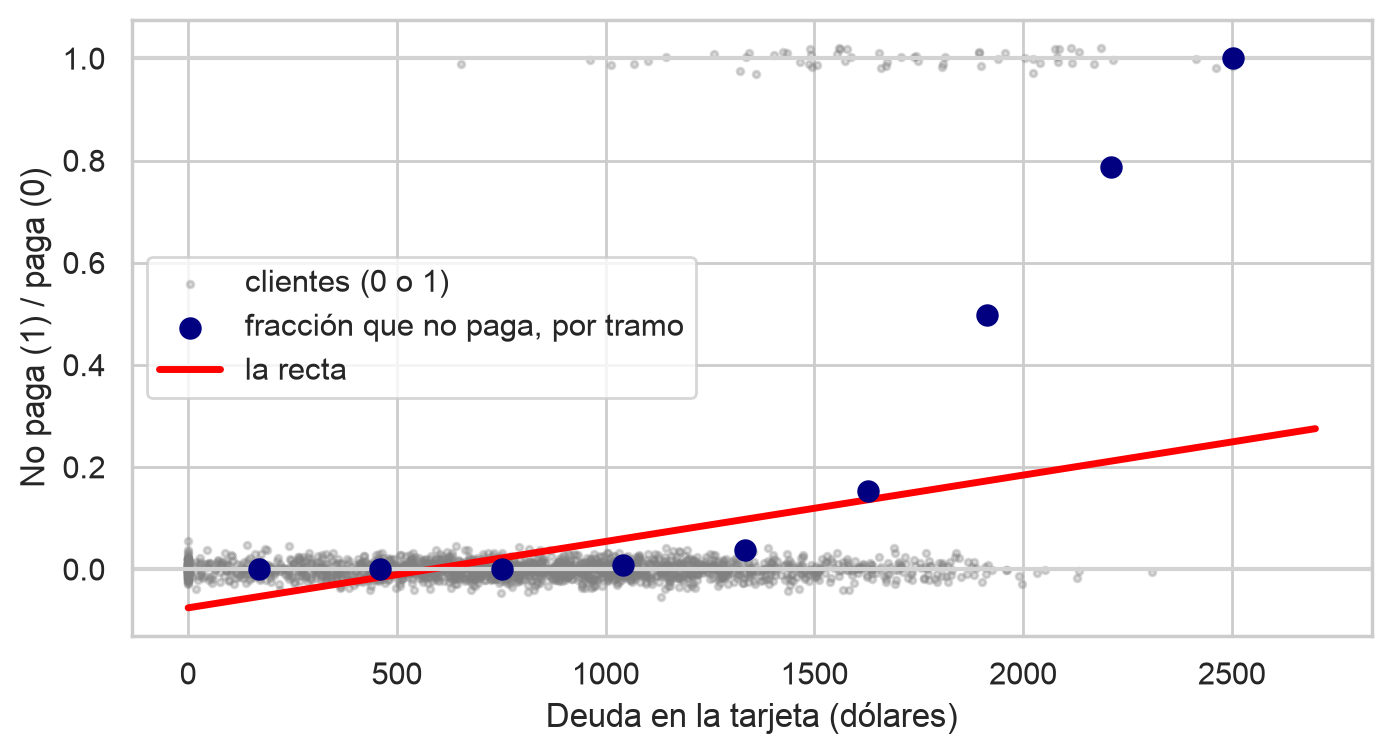

In [7]:
ok = por_tramo
grilla = np.linspace(0, 2700, 200)

fig, ax = plt.subplots(figsize=(8, 4))
muestra = clientes.sample(2000, random_state=1)
# un poco de ruido vertical para que los 0 y los 1 no se tapen
ax.scatter(muestra["balance"], muestra["no_paga"] + np.random.default_rng(1).normal(0, 0.015, len(muestra)), s=6, alpha=0.3, color="gray", label="clientes (0 o 1)")
ax.scatter(ok["deuda"], ok["fraccion"], s=50, color="navy", zorder=5, label="fracción que no paga, por tramo")
ax.plot(grilla, a_r + b_r * grilla / 100, color="red", lw=2.5, label="la recta")
ax.axhline(0, color="lightgray"); ax.axhline(1, color="lightgray")
ax.set(xlabel="Deuda en la tarjeta (dólares)", ylabel="No paga (1) / paga (0)")
ax.legend()
plt.show()

Con deuda 0 la recta predice una probabilidad negativa, y a los 2.000 dólares predice 0,18 cuando en los datos la mitad de ese tramo no paga. Una probabilidad vive entre 0 y 1 y sube en forma de S; la recta no respeta ninguna de las dos cosas.

## 4. La regresión logística

**Objetivo:** ajustar la curva en S y leer sus coeficientes.

La **regresión logística** toma la misma recta $a + b\,x$ y la pasa por la **sigmoide**, una función que convierte cualquier número en una probabilidad entre 0 y 1:

$$P(y = 1 \mid x) = \frac{1}{1 + e^{-(a + b\,x)}}$$

donde $P(y = 1 \mid x)$ es la probabilidad de un sí dado $x$, y $a + b\,x$ es la recta. La misma ecuación, despejada, dice que la recta es el logaritmo de las **chances** (odds), la razón sí contra no:

$$\log\frac{P}{1 - P} = a + b\,x$$

Con $P = 0{,}8$ las chances son $0{,}8 / 0{,}2 = 4$: cuatro síes por cada no. Y como la recta está en escala de logaritmo, $e^{b}$ dice cuánto se **multiplican** las chances por cada unidad de $x$, igual que el modelo en log de la clase 4.

En statsmodels es `smf.logit`, con la misma sintaxis de fórmulas que `smf.ols`. No se ajusta por mínimos cuadrados (con un 0/1 no hay residuo que tenga sentido) sino por **máxima verosimilitud**: se buscan los $a$ y $b$ que hacen más probable haber observado exactamente estos síes y noes, por iteraciones.

In [8]:
logistica = smf.logit("no_paga ~ deuda_100", data=clientes).fit()
a, b = logistica.params
print(f"\na = {a:.2f}, b = {b:.3f} por cada 100 dólares de deuda")
print(f"e^b = {np.exp(b):.2f}: cada 100 dólares más de deuda multiplican las chances de no pagar por {np.exp(b):.1f}")

Optimization terminated successfully.
         Current function value: 0.079823
         Iterations 10

a = -10.65, b = 0.550 por cada 100 dólares de deuda
e^b = 1.73: cada 100 dólares más de deuda multiplican las chances de no pagar por 1.7


La salida del ajuste muestra las iteraciones (`Optimization terminated successfully`): es la máxima verosimilitud trabajando. La curva, y qué probabilidad da para distintos deudas:

In [9]:
def sigmoide(z):
    return 1 / (1 + np.exp(-z))

for deuda in [500, 1000, 1500, 2000, 2500]:
    print(f"deuda {deuda:>5} dólares: P(no paga) = {sigmoide(a + b * deuda / 100):.3f}")
print(f"la curva cruza 0,5 en {-a / b * 100:.0f} dólares")

deuda   500 dólares: P(no paga) = 0.000
deuda  1000 dólares: P(no paga) = 0.006
deuda  1500 dólares: P(no paga) = 0.083
deuda  2000 dólares: P(no paga) = 0.586
deuda  2500 dólares: P(no paga) = 0.957
la curva cruza 0,5 en 1937 dólares


In [10]:
# lo mismo con predict: recibe una tabla con la columna del modelo y devuelve probabilidades
nuevos = pd.DataFrame({"deuda_100": [5, 10, 15, 20, 25]})
nuevos["P_no_paga"] = logistica.predict(nuevos)
nuevos

,deuda_100,P_no_paga
0,5,0.000
1,10,0.006
2,15,0.083
3,20,0.586
4,25,0.957


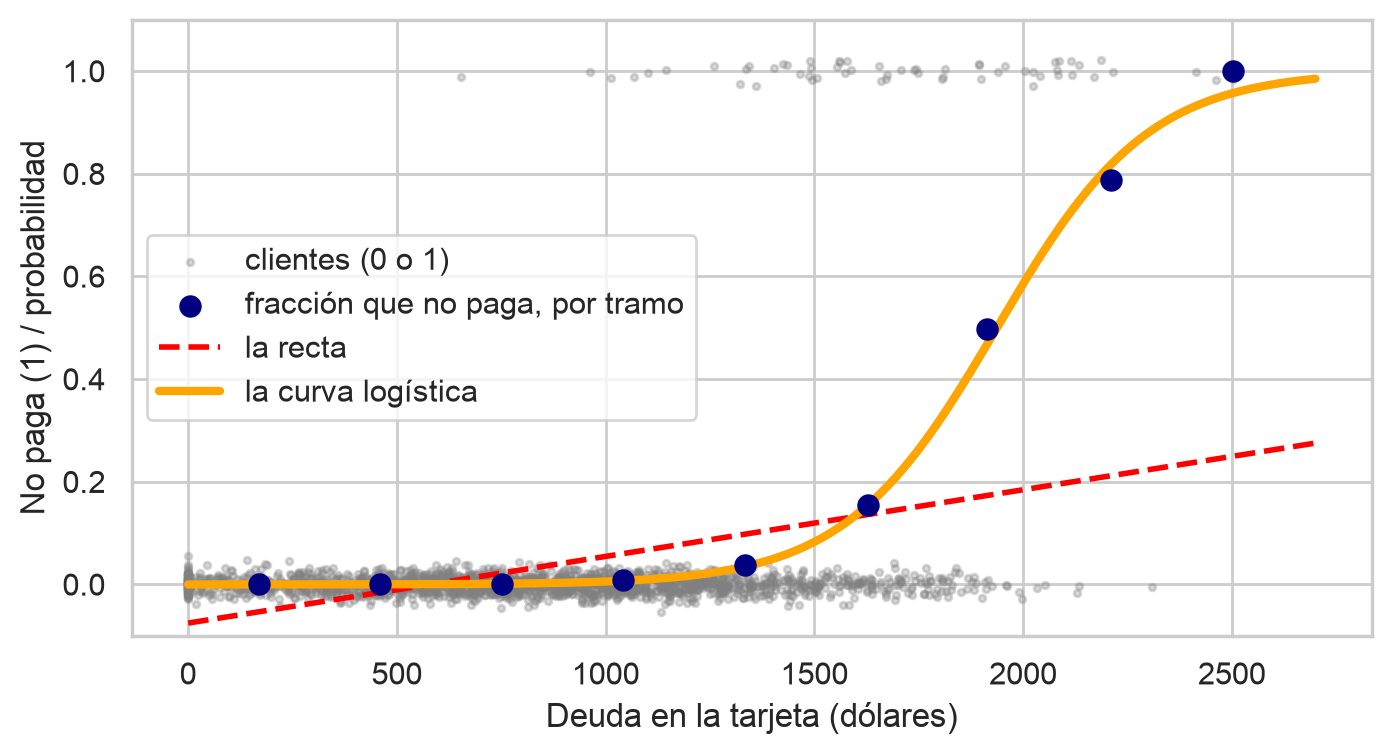

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(muestra["balance"], muestra["no_paga"] + np.random.default_rng(1).normal(0, 0.015, len(muestra)), s=6, alpha=0.3, color="gray", label="clientes (0 o 1)")
ax.scatter(ok["deuda"], ok["fraccion"], s=50, color="navy", zorder=5, label="fracción que no paga, por tramo")
ax.plot(grilla, a_r + b_r * grilla / 100, color="red", lw=2, ls="--", label="la recta")
ax.plot(grilla, sigmoide(a + b * grilla / 100), color="orange", lw=3, label="la curva logística")
ax.set(xlabel="Deuda en la tarjeta (dólares)", ylabel="No paga (1) / probabilidad", ylim=(-0.1, 1.1))
ax.legend()
plt.show()

La curva pasa por las fracciones de cada tramo: es la S que la recta no podía dibujar.

### El mismo summary

Las columnas son las de la clase 5: **coef**, **std err**, **z**, **P>|z|** y el intervalo. La única diferencia es $z$ en lugar de $t$: con 10.000 clientes la referencia es la normal en vez de la t de Student, y $P>|z|$ se lee igual que $P>|t|$.

In [12]:
logistica.summary().tables[1]

,coef,std err,z,P>|z|,[0.025,0.975]
Intercept,-10.6513,0.361,-29.491,0.000,-11.359,-9.943
deuda_100,0.5499,0.022,24.952,0.000,0.507,0.593


El intervalo de $b$ también se puede pasar a chances con `np.exp`: el multiplicador por cada 100 dólares está entre 1,66 y 1,81.

In [13]:
intervalo = logistica.conf_int().loc["deuda_100"]
print(f"b entre {intervalo.iloc[0]:.3f} y {intervalo.iloc[1]:.3f}")
print(f"e^b entre {np.exp(intervalo.iloc[0]):.2f} y {np.exp(intervalo.iloc[1]):.2f}")

b entre 0.507 y 0.593
e^b entre 1.66 y 1.81


## 5. Varias variables

**Objetivo:** agregar variables, numéricas y dummies, y leer cada e^b.

Los estudiantes, solos, dejan de pagar más que el resto:

In [14]:
print(clientes.groupby("student")["no_paga"].mean().rename("fracción que no paga"))
print(clientes.groupby("student")["balance"].mean().rename("deuda media"))

solo_estudiante = smf.logit("no_paga ~ estudiante", data=clientes).fit(disp=0)
print(f"\nsolo estudiante: b = {solo_estudiante.params['estudiante']:.3f}, e^b = {np.exp(solo_estudiante.params['estudiante']):.2f}")

student
No    0.029
Yes   0.043
Name: fracción que no paga, dtype: float64
student
No    771.770
Yes   987.818
Name: deuda media, dtype: float64

solo estudiante: b = 0.405, e^b = 1.50


Pero los estudiantes también deben más. ¿Qué pasa con el coeficiente de estudiante cuando la deuda entra al modelo? Es la misma pregunta de la regresión múltiple de la clase 4, y `estudiante` es una dummy como lo era el modo de transporte:

In [15]:
multiple = smf.logit("no_paga ~ deuda_100 + ingreso_miles + estudiante", data=clientes).fit(disp=0)
multiple.summary().tables[1]

,coef,std err,z,P>|z|,[0.025,0.975]
Intercept,-10.8690,0.492,-22.079,0.000,-11.834,-9.904
deuda_100,0.5737,0.023,24.737,0.000,0.528,0.619
ingreso_miles,0.0030,0.008,0.370,0.712,-0.013,0.019
estudiante,-0.6468,0.236,-2.738,0.006,-1.110,-0.184


In [16]:
np.exp(multiple.params).rename("e^b: multiplicador de las chances")

Intercept       0.000
deuda_100       1.775
ingreso_miles   1.003
estudiante      0.524
Name: e^b: multiplicador de las chances, dtype: float64

El coeficiente de estudiante cambió de signo: a igual deuda e ingreso, las chances de un estudiante son la **mitad** (e^b = 0,52). Solos parecían peores pagadores porque deben más, y lo que explica el no pago es la deuda. Es la confusión de variables de la clase 4, ahora en la logística. El ingreso no aporta nada con la deuda en el modelo (p = 0,71).

### Ejemplo 2: el Titanic

891 pasajeros, del repositorio de datos de ejemplo de seaborn. La respuesta es si sobrevivieron; las variables, el sexo, la clase del pasaje (1, 2 o 3) y la edad, que falta en 177 pasajeros: el modelo usa los 714 con edad conocida.

In [17]:
pasajeros = pd.read_csv(BASE + "titanic.csv")
pasajeros["sobrevivio"] = pasajeros["survived"]
pasajeros["sexo"] = pasajeros["sex"].map({"female": "mujer", "male": "hombre"})
pasajeros["clase"] = pasajeros["pclass"]
pasajeros["edad"] = pasajeros["age"]
print("pasajeros:", len(pasajeros), "| sobrevivió:", round(pasajeros["sobrevivio"].mean(), 3), "| sin edad:", pasajeros["edad"].isna().sum())
pasajeros.groupby(["clase", "sexo"])["sobrevivio"].mean().unstack()

pasajeros: 891 | sobrevivió: 0.384 | sin edad: 177


sexo,hombre,mujer
clase,,
1,0.369,0.968
2,0.157,0.921
3,0.135,0.500


La clase es categórica aunque sea un número: `C(clase)` le dice a statsmodels que cree las dummies (segunda y tercera clase, con la primera como referencia). El sexo es texto, así que la dummy se crea sola, con `hombre` como referencia por orden alfabético.

In [18]:
con_edad = pasajeros.dropna(subset=["edad"])
titanic = smf.logit("sobrevivio ~ sexo + C(clase) + edad", data=con_edad).fit(disp=0)
titanic.summary().tables[1]

,coef,std err,z,P>|z|,[0.025,0.975]
Intercept,1.2542,0.360,3.485,0.000,0.549,1.960
sexo[T.mujer],2.5228,0.207,12.164,0.000,2.116,2.929
C(clase)[T.2],-1.3098,0.278,-4.710,0.000,-1.855,-0.765
C(clase)[T.3],-2.5806,0.281,-9.169,0.000,-3.132,-2.029
edad,-0.0370,0.008,-4.831,0.000,-0.052,-0.022


In [19]:
np.exp(titanic.params).rename("e^b: multiplicador de las chances")

Intercept        3.505
sexo[T.mujer]   12.463
C(clase)[T.2]    0.270
C(clase)[T.3]    0.076
edad             0.964
Name: e^b: multiplicador de las chances, dtype: float64

Cada e^b compara con su referencia, a igualdad de las otras variables: las chances de sobrevivir de una mujer son 12 veces las de un hombre; las de la tercera clase, el 8% de las de la primera; y cada año de edad las multiplica por 0,96. Con varias variables, `predict` suma los aportes en la recta y la sigmoide entrega la probabilidad:

In [20]:
perfiles = pd.DataFrame({
    "sexo": ["mujer", "mujer", "hombre", "hombre"],
    "clase": [1, 3, 1, 3],
    "edad": [30, 30, 30, 30],
})
perfiles["P_sobrevive"] = titanic.predict(perfiles)
perfiles

,sexo,clase,edad,P_sobrevive
0,mujer,1,30,0.935
1,mujer,3,30,0.522
2,hombre,1,30,0.536
3,hombre,3,30,0.080


## 6. Clasificar: de la probabilidad a la decisión

**Objetivo:** convertir la probabilidad en un sí o no, y medir los dos errores.

El modelo entrega probabilidades. Para decidir hace falta un **umbral**: el más simple es 0,5. La tabla de lo real contra lo predicho es la **matriz de confusión**, y tiene cuatro celdas con nombre:

| | predicho sí | predicho no |
|---|---|---|
| **real sí** | verdadero positivo (VP) | **falso negativo (FN)** |
| **real no** | **falso positivo (FP)** | verdadero negativo (VN) |

Un **falso negativo** es un sí que el modelo declaró no: un cliente que no pagará y recibió la tarjeta. Un **falso positivo** es un no declarado sí: un cliente que sí pagaba y a quien se le negó. No cuestan lo mismo, y cuál cuesta más lo dice el problema, no el modelo.

In [21]:
clientes["prob"] = logistica.predict(clientes)
clientes["prediccion"] = (clientes["prob"] >= 0.5).astype(int)

# La matriz de confusión: crosstab de lo real contra lo predicho
pd.crosstab(clientes["no_paga"], clientes["prediccion"], rownames=["real"], colnames=["predicho"])

predicho,0,1
real,,
0,9625,42
1,233,100


De los 333 clientes que no pagan, el modelo detecta 100 y se le escapan 233 (falsos negativos); a 42 clientes que sí pagan los declara morosos (falsos positivos). ¿Y la **exactitud**, la fracción de aciertos?

In [22]:
exactitud = (clientes["prediccion"] == clientes["no_paga"]).mean()
base = 1 - clientes["no_paga"].mean()   # decir siempre "paga", la clase mayoritaria
print(f"exactitud del modelo: {exactitud:.4f}")
print(f"decir siempre \"paga\": {base:.4f}")

exactitud del modelo: 0.9725
decir siempre "paga": 0.9667


97,3% contra 96,7%: casi lo mismo que no tener modelo. Cuando el sí es raro (3,3%), la exactitud mide sobre todo lo fácil, los noes. Hay que mirar los dos errores por separado, con dos números que salen de la misma matriz:

- **Sensibilidad** = VP / (VP + FN): de los que eran sí, qué fracción detectó el modelo.
- **Especificidad** = VN / (VN + FP): de los que eran no, qué fracción dejó en paz.

In [23]:
def evaluar(real, prob, umbral):
    """Cuenta las cuatro celdas de la matriz de confusión para un umbral y devuelve las medidas."""
    pred = (prob >= umbral).astype(int)
    VP = ((pred == 1) & (real == 1)).sum()
    FN = ((pred == 0) & (real == 1)).sum()
    FP = ((pred == 1) & (real == 0)).sum()
    VN = ((pred == 0) & (real == 0)).sum()
    return pd.Series({"umbral": umbral, "VP": VP, "FN": FN, "FP": FP, "VN": VN,
                      "sensibilidad": VP / (VP + FN), "especificidad": VN / (VN + FP),
                      "exactitud": (VP + VN) / len(real)})

evaluar(clientes["no_paga"], clientes["prob"], 0.5)

umbral             0.500
VP               100.000
FN               233.000
FP                42.000
VN              9625.000
sensibilidad       0.300
especificidad      0.996
exactitud          0.973
dtype: float64

Sensibilidad 0,30: el modelo con umbral 0,5 detecta solo 3 de cada 10 clientes que no pagan. Especificidad 0,996: casi no molesta a los que pagan. Si al banco le cuesta más el falso negativo (el dinero perdido), conviene **bajar el umbral**: declarar moroso desde una probabilidad menor, a cambio de más falsos positivos.

In [24]:
tabla_umbrales = pd.DataFrame([evaluar(clientes["no_paga"], clientes["prob"], u) for u in [0.5, 0.3, 0.2, 0.1]])
tabla_umbrales

,umbral,VP,FN,FP,VN,sensibilidad,especificidad,exactitud
0,0.500,100.000,233.000,42.000,9625.000,0.300,0.996,0.973
1,0.300,167.000,166.000,147.000,9520.000,0.502,0.985,0.969
2,0.200,199.000,134.000,263.000,9404.000,0.598,0.973,0.960
3,0.100,244.000,89.000,550.000,9117.000,0.733,0.943,0.936


Con umbral 0,2 se detectan 199 de los 333 (sensibilidad 0,60) a cambio de 263 falsos positivos; la exactitud baja, y no importa. No hay umbral correcto: hay un balance entre los dos errores, y lo fija el costo de cada uno. Recorriendo todos los umbrales se ve el balance completo, y la **curva ROC** lo resume en un solo gráfico: sensibilidad contra 1 − especificidad, un punto por umbral.

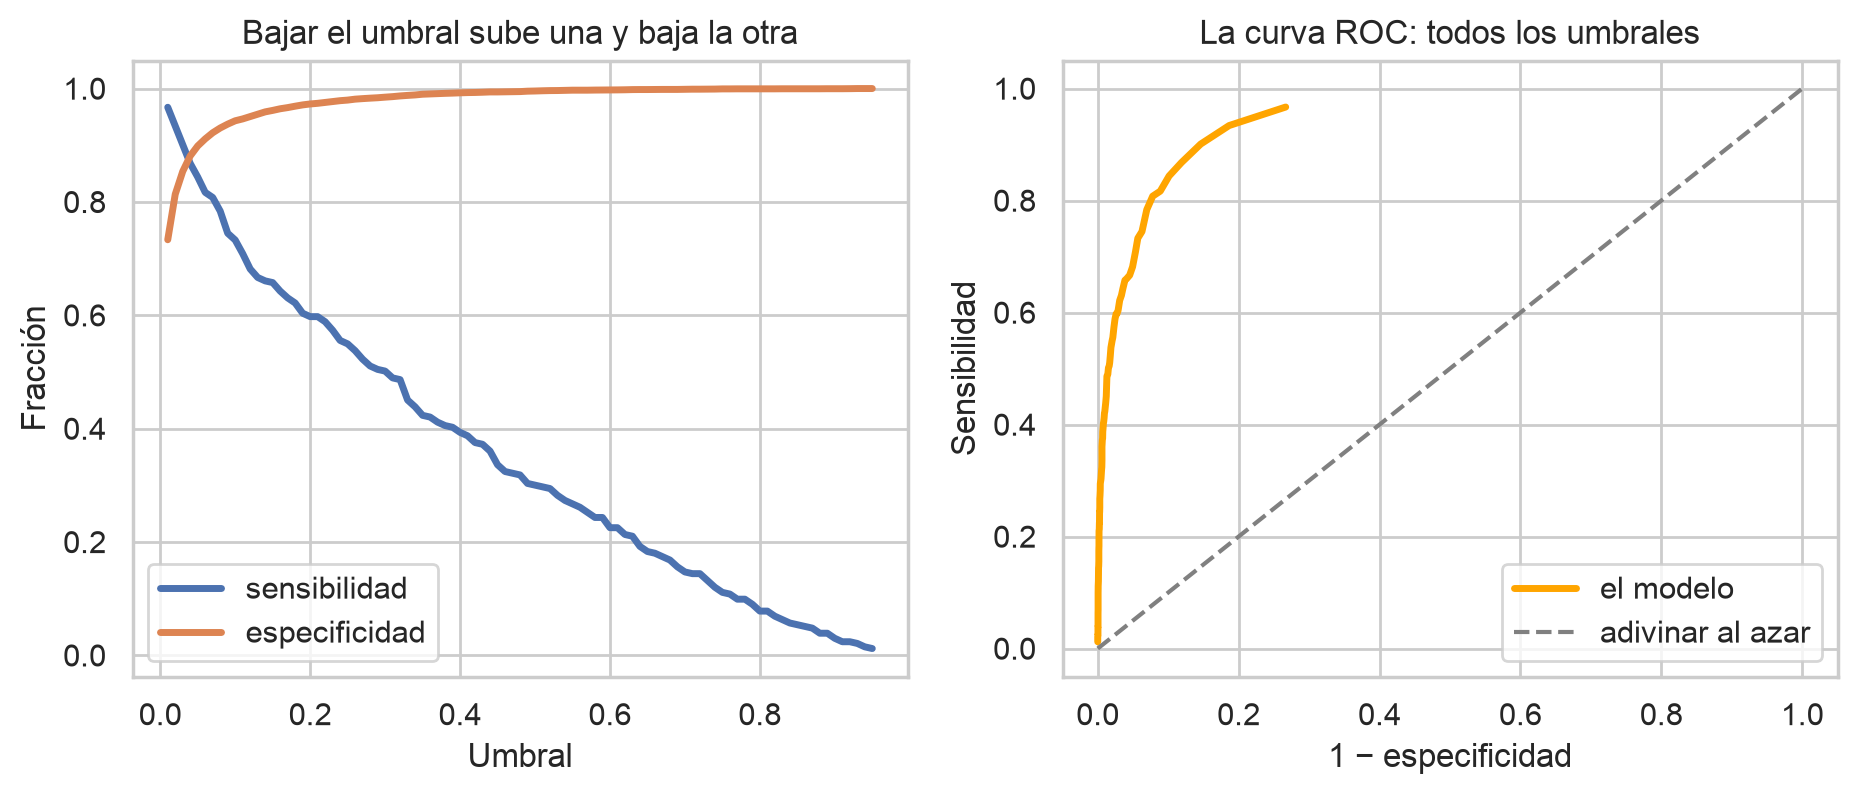

In [25]:
umbrales = np.linspace(0.01, 0.95, 95)
curva = pd.DataFrame([evaluar(clientes["no_paga"], clientes["prob"], u) for u in umbrales])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(curva["umbral"], curva["sensibilidad"], lw=2.5, label="sensibilidad")
axes[0].plot(curva["umbral"], curva["especificidad"], lw=2.5, label="especificidad")
axes[0].set(xlabel="Umbral", ylabel="Fracción", title="Bajar el umbral sube una y baja la otra")
axes[0].legend()
axes[1].plot(1 - curva["especificidad"], curva["sensibilidad"], lw=2.5, color="orange", label="el modelo")
axes[1].plot([0, 1], [0, 1], "--", color="gray", label="adivinar al azar")
axes[1].set(xlabel="1 − especificidad", ylabel="Sensibilidad", title="La curva ROC: todos los umbrales")
axes[1].legend()
plt.show()

### El Titanic como clasificador

Con un sí frecuente (41% sobrevivió), la exactitud sí informa:

In [26]:
con_edad = con_edad.copy()
con_edad["prob"] = titanic.predict(con_edad)
print(pd.crosstab(con_edad["sobrevivio"], (con_edad["prob"] >= 0.5).astype(int), rownames=["real"], colnames=["predicho"]))
print(f"\ndecir siempre \"murió\": exactitud {1 - con_edad['sobrevivio'].mean():.3f}")
evaluar(con_edad["sobrevivio"], con_edad["prob"], 0.5)

predicho    0    1
real              
0         356   68
1          83  207

decir siempre "murió": exactitud 0.594


umbral            0.500
VP              207.000
FN               83.000
FP               68.000
VN              356.000
sensibilidad      0.714
especificidad     0.840
exactitud         0.789
dtype: float64

79% de aciertos contra el 59% de decir que todos murieron: el modelo aporta 20 puntos. Se equivoca más con los que sobrevivieron (sensibilidad 0,71): hombres jóvenes de tercera clase que el modelo daba por muertos.

## 7. Evaluar fuera de la muestra

**Objetivo:** medir el modelo en datos que no usó para ajustarse.

Todas las exactitudes anteriores se midieron en los mismos datos con que se ajustó el modelo, y eso es hacer trampa: el modelo ya los vio. La medida honesta se toma en una parte de **prueba** separada al azar antes de ajustar; la otra parte, de **entrenamiento**, es la única que ve el modelo.

In [27]:
rng = np.random.default_rng(7)
en_entrenamiento = rng.random(len(con_edad)) < 0.7   # True para el 70% de las filas, al azar
entrenamiento = con_edad[en_entrenamiento]
prueba = con_edad[~en_entrenamiento]
print(f"entrenamiento: {len(entrenamiento)} pasajeros | prueba: {len(prueba)}")

modelo_e = smf.logit("sobrevivio ~ sexo + C(clase) + edad", data=entrenamiento).fit(disp=0)
for nombre, datos in [("entrenamiento", entrenamiento), ("prueba", prueba)]:
    aciertos = ((modelo_e.predict(datos) >= 0.5).astype(int) == datos["sobrevivio"]).mean()
    print(f"exactitud en {nombre}: {aciertos:.3f}")

entrenamiento: 496 pasajeros | prueba: 218


exactitud en entrenamiento: 0.778
exactitud en prueba: 0.830


Con un modelo simple como este las dos cifras se parecen, y que la de prueba salga un poco más alta o más baja es cosa del azar del reparto: buena señal, el modelo no aprendió el azar de su muestra. Con modelos más flexibles la exactitud de entrenamiento sube y la de prueba no, y la de prueba es la única que vale. Este es el punto de partida de la evaluación de modelos que sigue en el diplomado.

---

**Próxima clase (martes 15-sep):** regresión regularizada, Ridge y Lasso, para modelos con muchas variables. Recuerde: el primer análisis exploratorio se entrega el martes 15 de septiembre.